# Gold — Análisis Científico y Outputs
**Pipeline stage:** `GOLD`

Construimos los dos outputs Gold según el Data Contract:

| Gold table | Descripción científica |
|---|---|
| `gold_by_spectral_class` | Estadísticas planetarias y estelares por clase espectral |
| `gold_hr_diagram` | Datos para el Diagrama HR con clasificación de región |

**Pregunta científica:**  
> *¿Cómo varía la arquitectura de los sistemas planetarios (tamaño, período orbital, temperatura de equilibrio) según la clase espectral de la estrella anfitriona?*


In [1]:
import pandas as pd, numpy as np
import duckdb, pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

os.makedirs("../artifacts", exist_ok=True)

con = duckdb.connect()
con.execute("CREATE VIEW dim  AS SELECT * FROM read_parquet('../data/gold/dim_host_sk.parquet')")
con.execute("CREATE VIEW fact AS SELECT * FROM read_parquet('../data/gold/fact_planet_sk.parquet')")

print("Vistas DuckDB listas")

Vistas DuckDB listas


## Gold Tabla 1 — `gold_by_spectral_class`

In [3]:
gold_spectral = con.execute("""
    SELECT
        d.spectral_class,
        COUNT(DISTINCT d.host_id) AS n_host_stars,
        COUNT(f.pl_name) AS n_planets,
        ROUND(AVG(d.st_teff_k), 0) AS avg_teff_k,
        ROUND(AVG(d.st_mass_msun), 3) AS avg_mass_msun,
        ROUND(AVG(d.st_rad_rsun), 3) AS avg_rad_rsun,
        ROUND(AVG(d.st_lum_log), 3) AS avg_lum_log,
        ROUND(AVG(f.pl_rad_rearth), 2) AS avg_pl_rad_rearth,
        ROUND(AVG(f.pl_orbper_d), 1) AS avg_pl_orbper_d,
        ROUND(AVG(f.pl_eqt_k), 1) AS avg_pl_eqt_k,
        SUM(CASE WHEN f.hab_zone_flag=1 THEN 1 ELSE 0 END) AS hz_planets,
        ROUND(100.0*SUM(CASE WHEN f.pl_size_class='Rocky' THEN 1 ELSE 0 END)/COUNT(*), 1) AS pct_rocky
    FROM dim d
    JOIN fact f ON d.host_id = f.host_id
    WHERE d.spectral_class != 'Unknown'
    GROUP BY d.spectral_class
    ORDER BY avg_teff_k DESC
""").df()

print(gold_spectral.to_string())

gold_spectral.to_csv("../artifacts/gold_by_spectral_class.csv", index=False)
print("\nGuardado: artifacts/gold_by_spectral_class.csv")

  spectral_class  n_host_stars  n_planets  avg_teff_k  avg_mass_msun  avg_rad_rsun  avg_lum_log  avg_pl_rad_rearth  avg_pl_orbper_d  avg_pl_eqt_k  hz_planets  pct_rocky
0              B             7          8     15990.0          2.983         2.037        1.604              10.60              0.7        2775.0         0.0       25.0
1              A            20         24      7747.0          1.760         1.683        0.952              15.78          19504.8        1764.9         0.0        0.0
2              F           236        286      6261.0          1.291         1.494        0.468              12.43            828.8        1468.0         3.0        0.3
3              G           564        780      5627.0          1.068         1.669        0.184               9.49            949.2        1090.5        14.0        3.5
4              K           436        646      4840.0          1.037         3.858        0.010               8.53            913.5         818.9        10

## Gold Tabla 2 — `gold_hr_diagram`

In [4]:
gold_hr = con.execute("""
    SELECT
        d.host_id,
        d.hostname,
        d.st_teff_k,
        d.st_lum_log,
        d.st_mass_msun,
        d.st_rad_rsun,
        d.spectral_class,
        d.hr_region,
        COUNT(f.pl_name) AS n_planets,
        ROUND(AVG(f.pl_rad_rearth),2) AS avg_pl_rad,
        MAX(CASE WHEN f.hab_zone_flag=1 THEN 1 ELSE 0 END) AS has_hz_planet
    FROM dim d
    LEFT JOIN fact f ON d.host_id = f.host_id
    WHERE d.st_teff_k IS NOT NULL
      AND d.st_lum_log IS NOT NULL
      AND d.hr_region  != 'Unknown'
    GROUP BY d.host_id, d.hostname, d.st_teff_k, d.st_lum_log,
             d.st_mass_msun, d.st_rad_rsun, d.spectral_class, d.hr_region
""").df()

print(f"gold_hr_diagram shape: {gold_hr.shape}")
gold_hr.head(3)

gold_hr_diagram shape: (4269, 11)


,host_id,hostname,st_teff_k,st_lum_log,st_mass_msun,st_rad_rsun,spectral_class,hr_region,n_planets,avg_pl_rad,has_hz_planet
0,3147,Kepler-644,6747.0,0.71041,1.490,1.810,Unknown,Main_Sequence_Hot,1,3.15,0
1,1692,Kepler-1101,5614.0,-0.35135,0.940,0.910,Unknown,Main_Sequence_Cool,1,2.47,0
2,2245,Kepler-1600,5166.5,-0.33945,0.839,0.827,Unknown,Main_Sequence_Cool,2,2.54,1


In [5]:
gold_hr.to_csv("../artifacts/gold_hr_diagram.csv", index=False)
print("Guardado: artifacts/gold_hr_diagram.csv")
print(f"{len(gold_hr):,} estrellas con coordenadas HR válidas")
print("\nDistribución por región HR:")
print(gold_hr["hr_region"].value_counts().to_string())

Guardado: artifacts/gold_hr_diagram.csv
4,269 estrellas con coordenadas HR válidas

Distribución por región HR:
hr_region
Main_Sequence_Cool    3113
Main_Sequence_Hot      795
Subgiant               159
Giant                  131
Supergiant              71


## Visualización — Diagrama de Hertzsprung-Russell

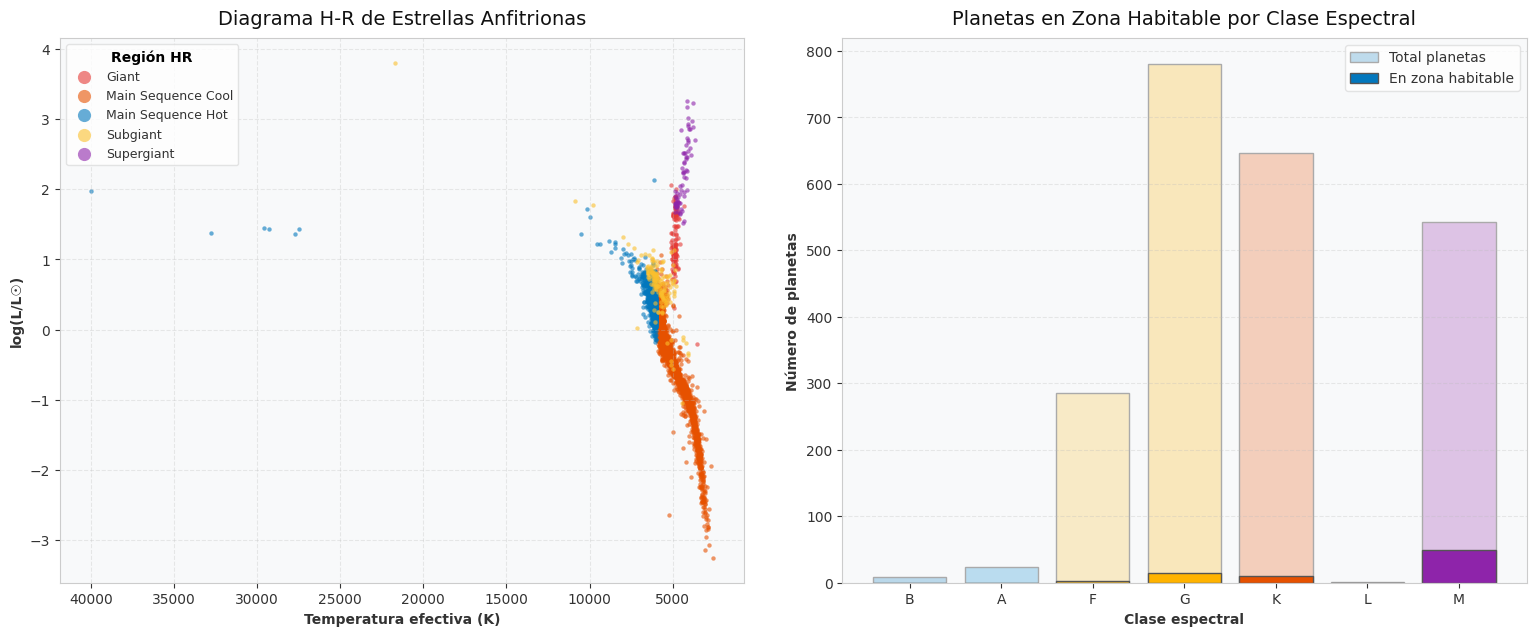

Guardado: artifacts/hr_diagram_analysis.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#ffffff") 

COLORS = {
    "Main_Sequence_Hot" : "#0277bd",  # Azul oscuro
    "Main_Sequence_Cool": "#e65100",  # Naranja oscuro
    "Subgiant"          : "#fbc02d",  # Amarillo fuerte
    "Giant"             : "#e53935",  # Rojo 
    "Supergiant"        : "#8e24aa",  # Púrpura
    "Unknown"           : "#9e9e9e",  # Gris
}

#Panel 1: HR Diagram clásico
ax = axes[0]
ax.set_facecolor("#f8f9fa")
for region, grp in gold_hr.groupby("hr_region"):
    ax.scatter(grp["st_teff_k"], grp["st_lum_log"],
               c=COLORS.get(region, "#888"),
               s=10, alpha=0.6, label=region.replace("_", " "), linewidths=0)
ax.invert_xaxis()
ax.set_xlabel("Temperatura efectiva (K)", color="#333333", fontweight="bold")
ax.set_ylabel("log(L/L☉)", color="#333333", fontweight="bold")
ax.set_title("Diagrama H-R de Estrellas Anfitrionas", color="#111111", fontsize=14, pad=10)
ax.tick_params(colors="#333333") 
for spine in ax.spines.values():
    spine.set_color("#cccccc")

# Leyenda Panel 1
legend1 = ax.legend(fontsize=9, facecolor="#ffffff", edgecolor="#dddddd", labelcolor="#333333",
                    markerscale=3, title="Región HR", title_fontsize=10)
legend1.get_title().set_fontweight("bold")

# Panel 2: Planetas en zona habitable por clase espectral
ax2 = axes[1]
ax2.set_facecolor("#f8f9fa")

hz = gold_spectral[gold_spectral["spectral_class"] != "Unknown"].copy()
hz = hz.sort_values("avg_teff_k", ascending=False)

# Colores para las barras (de O a M)
bar_colors_solid = ["#0277bd", "#0288d1", "#fbc02d", "#ffb300", "#e65100", "#e53935", "#8e24aa"]
bar_colors_faint = [c + "40" for c in bar_colors_solid] # 40 = 25% opacidad en hex

# Barras de total planetas
ax2.bar(hz["spectral_class"], hz["n_planets"],
        color=bar_colors_faint, edgecolor="#aaaaaa", linewidth=1, label="Total planetas")

# Barras de planetas en zona habitable (sólidas)
ax2.bar(hz["spectral_class"], hz["hz_planets"],
        color=bar_colors_solid, edgecolor="#555555", linewidth=1, label="En zona habitable")

ax2.set_xlabel("Clase espectral", color="#333333", fontweight="bold")
ax2.set_ylabel("Número de planetas", color="#333333", fontweight="bold")
ax2.set_title("Planetas en Zona Habitable por Clase Espectral", color="#111111", fontsize=14, pad=10)
ax2.tick_params(colors="#333333")
for spine in ax2.spines.values():
    spine.set_color("#cccccc")

# Leyenda Panel 2
ax2.legend(facecolor="#ffffff", edgecolor="#dddddd", labelcolor="#333333", fontsize=10)

ax.grid(True, linestyle="--", alpha=0.3, color="#bbbbbb")
ax2.grid(True, linestyle="--", alpha=0.3, color="#bbbbbb", axis="y")

plt.tight_layout(pad=3)

plt.savefig("../artifacts/hr_diagram_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="#ffffff")
plt.show()
print("Guardado: artifacts/hr_diagram_analysis.png")

## Validaciones Gold (checks finales)

In [16]:
print("=" * 60)
print("GOLD VALIDATION CHECKS")
print("=" * 60)

# Check: gold_by_spectral_class tiene filas
c1 = len(gold_spectral) > 0
print(f"[{'PASS' if c1 else 'FAIL'}] gold_by_spectral_class tiene {len(gold_spectral)} filas")

# Check: gold_hr_diagram no tiene duplicados en host_id
c2 = gold_hr["host_id"].duplicated().sum() == 0
print(f"[{'PASS' if c2 else 'FAIL'}] gold_hr_diagram sin duplicados de host_id")

# Check: artefactos CSV existen
for fname in ["gold_by_spectral_class.csv", "gold_hr_diagram.csv",
              "dim_host_sk.csv", "fact_planet_sk.csv"]:
    exists = os.path.exists(f"../artifacts/{fname}")
    print(f"[{'PASS' if exists else 'FAIL'}] artifacts/{fname}")

print()
total_artifacts = len(os.listdir("../artifacts"))
print(f"Total artefactos en artifacts/: {total_artifacts}")

GOLD VALIDATION CHECKS
[PASS] gold_by_spectral_class tiene 7 filas
[PASS] gold_hr_diagram sin duplicados de host_id
[PASS] artifacts/gold_by_spectral_class.csv
[PASS] artifacts/gold_hr_diagram.csv
[PASS] artifacts/dim_host_sk.csv
[PASS] artifacts/fact_planet_sk.csv

Total artefactos en artifacts/: 5


## Checkpoint GOLD — Proyecto completo

### Resumen del pipeline

```
Raw (CSV + SHA256 + metadata.json)
  └─► Bronze-Lite (Parquet Snappy, tipos canónicos)
        └─► Silver (filtros físicos, spectral_class, hr_region, pl_size_class)
              └─► dim_host_sk (1 fila/estrella, host_id surrogate)
              └─► fact_planet_sk (1 fila/planeta, FK host_id)
                    ├─► gold_by_spectral_class.csv
                    └─► gold_hr_diagram.csv + hr_diagram_analysis.png
```

### Tres pilares
| Pilar | Evidencia |
|---|---|
| **Reliability** | Hash SHA-256 en raw, checks PK/FK/orphans, rangos físicos |
| **Scalability** | Parquet + Snappy, DuckDB SQL, columnar storage |
| **Maintainability** | Data contract, decisions_log, notebooks secuenciales |
